In [ ]:
!pip install openeo
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.0/357.0 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 7.8 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 68.8 MB/s eta 0:00:00


In [ ]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=WNUI-DNMR 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


Pengambilan data NO2

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-31", "2026-08-31"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["NO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi);

# Simpan hasil sebagai CSV
result = s5p_no2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_no2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_no2")

0:00:00 Job 'j-26091816142142078d9de40b30592177': send 'start'
0:00:04 Job 'j-26091816142142078d9de40b30592177': created (progress 0%)
0:00:09 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:00:16 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:00:24 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:00:34 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:00:46 Job 'j-26091816142142078d9de40b30592177': queued (progress 0%)
0:01:02 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:01:21 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:01:45 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:02:15 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:02:53 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:03:40 Job 'j-26091816142142078d9de40b30592177': running (progress N/A)
0:04:38 Job 'j-26091816142142078d9de40b30592177': finished (progress 100

[PosixPath('output_no2/timeseries.csv'),
 PosixPath('output_no2/job-results.json')]

Pengambilan Data SO₂

In [ ]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-28", "2026-08-28"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["SO2"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_so2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_so2_aoi = s5p_so2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_so2_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_so2_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_so2")

0:00:00 Job 'j-2609181620094370a85d9445731a8015': send 'start'
0:00:03 Job 'j-2609181620094370a85d9445731a8015': created (progress 0%)
0:00:09 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:00:15 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:00:23 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:00:33 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:00:46 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:01:01 Job 'j-2609181620094370a85d9445731a8015': queued (progress 0%)
0:01:21 Job 'j-2609181620094370a85d9445731a8015': running (progress N/A)
0:01:45 Job 'j-2609181620094370a85d9445731a8015': running (progress N/A)
0:02:15 Job 'j-2609181620094370a85d9445731a8015': running (progress N/A)
0:02:52 Job 'j-2609181620094370a85d9445731a8015': running (progress N/A)
0:03:39 Job 'j-2609181620094370a85d9445731a8015': finished (progress 100%)


[PosixPath('output_so2/timeseries.csv'),
 PosixPath('output_so2/job-results.json')]

Pengambilan data CO

In [ ]:
aoi = {
    "type": "Polygon",
    # Paste koordinat yang didapat
    "coordinates": [
        [
            [106.8988427, -6.9125063],
            [106.8978516, -6.9175151],
            [106.8983021, -6.9248493],
            [106.9001942, -6.930484],
            [106.9086634, -6.9414849],
            [106.9121802, -6.9506932],
            [106.916123, -6.9473549],
            [106.9211096, -6.9505781],
            [106.9279516, -6.9516141],
            [106.9346776, -6.9500025],
            [106.9330541, -6.9426352],
            [106.9306188, -6.9418294],
            [106.9343297, -6.9232953],
            [106.9358373, -6.9232953],
            [106.9359533, -6.9185753],
            [106.8988427, -6.9125063]
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-28", "2026-08-28"],
    spatial_extent={
        "west": 106.8978516,
        "south": -6.9516141,
        "east": 106.9359533,
        "north": -6.9125063
    },
    # Disesuaikan dengan data yang dibutuhkan
    bands=["CO"],
)

# Agregasi harian agar tidak ada lebih dari satu data per hari
s5p_co_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial untuk menghasilkan rata-rata time series per AOI
s5p_co_aoi = s5p_co_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# Simpan hasil sebagai CSV
result = s5p_co_aoi.save_result(format="CSV")

# Jalankan job
job = result.create_job(title="s5p_co_timeseries")
job.start_and_wait()

# Download
job.get_results().download_files("output_co")

0:00:00 Job 'j-2609181625264f96b28c80c8e8d8cfbe': send 'start'
0:00:03 Job 'j-2609181625264f96b28c80c8e8d8cfbe': created (progress 0%)
0:00:09 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:00:15 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:00:23 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:00:33 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:00:46 Job 'j-2609181625264f96b28c80c8e8d8cfbe': queued (progress 0%)
0:01:01 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:01:21 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:01:45 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:02:15 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:02:53 Job 'j-2609181625264f96b28c80c8e8d8cfbe': running (progress N/A)
0:03:39 Job 'j-2609181625264f96b28c80c8e8d8cfbe': finished (progress 100%)


[PosixPath('output_co/timeseries.csv'),
 PosixPath('output_co/job-results.json')]

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_no2/timeseries.csv")
df.head(10)

,date,feature_index,NO2
0,2025-09-30T00:00:00.000Z,0,NaN
1,2025-10-01T00:00:00.000Z,0,NaN
2,2025-10-02T00:00:00.000Z,0,NaN
3,2025-10-06T00:00:00.000Z,0,0.000014
4,2025-10-04T00:00:00.000Z,0,0.000045
5,2025-10-03T00:00:00.000Z,0,NaN
6,2025-10-05T00:00:00.000Z,0,NaN
7,2025-09-29T00:00:00.000Z,0,NaN
8,2026-01-17T00:00:00.000Z,0,NaN
9,2026-01-15T00:00:00.000Z,0,NaN


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_so2/timeseries.csv")
df.head(10)

,date,feature_index,SO2
0,2026-05-15T00:00:00.000Z,0,NaN
1,2026-05-17T00:00:00.000Z,0,-0.000056
2,2026-05-11T00:00:00.000Z,0,0.000146
3,2026-05-16T00:00:00.000Z,0,NaN
4,2026-05-18T00:00:00.000Z,0,-0.000264
5,2026-05-12T00:00:00.000Z,0,0.000298
6,2026-05-14T00:00:00.000Z,0,0.000166
7,2026-05-13T00:00:00.000Z,0,-0.000675
8,2025-11-06T00:00:00.000Z,0,NaN
9,2025-11-03T00:00:00.000Z,0,NaN


In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv("output_co/timeseries.csv")
df.head(10)

,date,feature_index,CO
0,2026-05-02T00:00:00.000Z,0,0.028663
1,2026-04-26T00:00:00.000Z,0,0.023476
2,2026-04-25T00:00:00.000Z,0,0.024172
3,2026-05-01T00:00:00.000Z,0,0.025755
4,2026-04-27T00:00:00.000Z,0,NaN
5,2026-04-29T00:00:00.000Z,0,0.028437
6,2026-04-30T00:00:00.000Z,0,0.033546
7,2026-04-28T00:00:00.000Z,0,NaN
8,2026-01-01T00:00:00.000Z,0,0.029457
9,2025-12-29T00:00:00.000Z,0,0.020568


Normalisasi Tanggal NO2

In [ ]:
import pandas as pd

df = pd.read_csv("output_no2/timeseries.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "NO2": df['NO2']
})

new_df.to_csv("NO2_Timeseries.csv", index=False)

Normalisasi Tanggal SO2

In [ ]:
import pandas as pd

df = pd.read_csv("output_so2/timeseries.csv")

# pastikan kolom tanggal valid
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# ambil hanya bulan dan tahun
df["date"] = df["date"].dt.strftime("%Y-%m-%d")

new_df = pd.DataFrame({
    "date": df['date'],
    "SO2": df['SO2']
})

new_df.to_csv("SO2_Timeseries.csv", index=False)

DETEKSI MISSING VALUE


In [ ]:
df = pd.read_csv("CO_Timeseries.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

169


In [ ]:
df = pd.read_csv("NO2_Timeseries.csv")
missing_value = df['NO2'].isna().sum()
print(missing_value)

51


In [ ]:
df = pd.read_csv("SO2_Timeseries.csv")
missing_value = df['SO2'].isna().sum()
print(missing_value)

58


In [ ]:
df = pd.read_csv("CO_Timeseries.csv")
missing_value = df['CO'].isna().sum()
print(missing_value)

57


Deteksi dan Visualisasi Outlier (Metode IQR) NO2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier (IQR): 7
         date           NO2
25 2025-09-24 -6.785994e-06
64 2025-11-02 -2.512900e-07
65 2025-11-03 -7.859995e-07
68 2025-11-06 -2.390128e-06
69 2025-11-07 -2.924838e-06


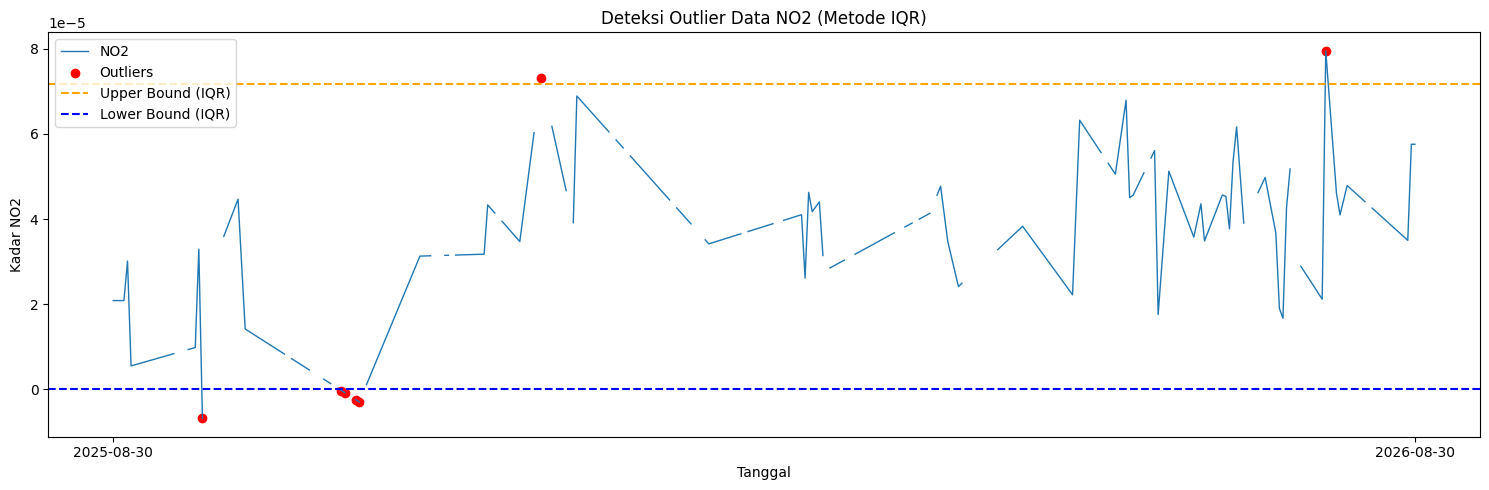

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Deteksi dan Visualisasi Outlier (Metode IQR) SO2


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'SO2']].head())

Jumlah Outlier (IQR): 6
          date       SO2
19  2025-09-15  0.000540
40  2025-10-06 -0.000510
165 2026-02-08  0.000546
259 2026-05-13 -0.000675
318 2026-07-11 -0.000506


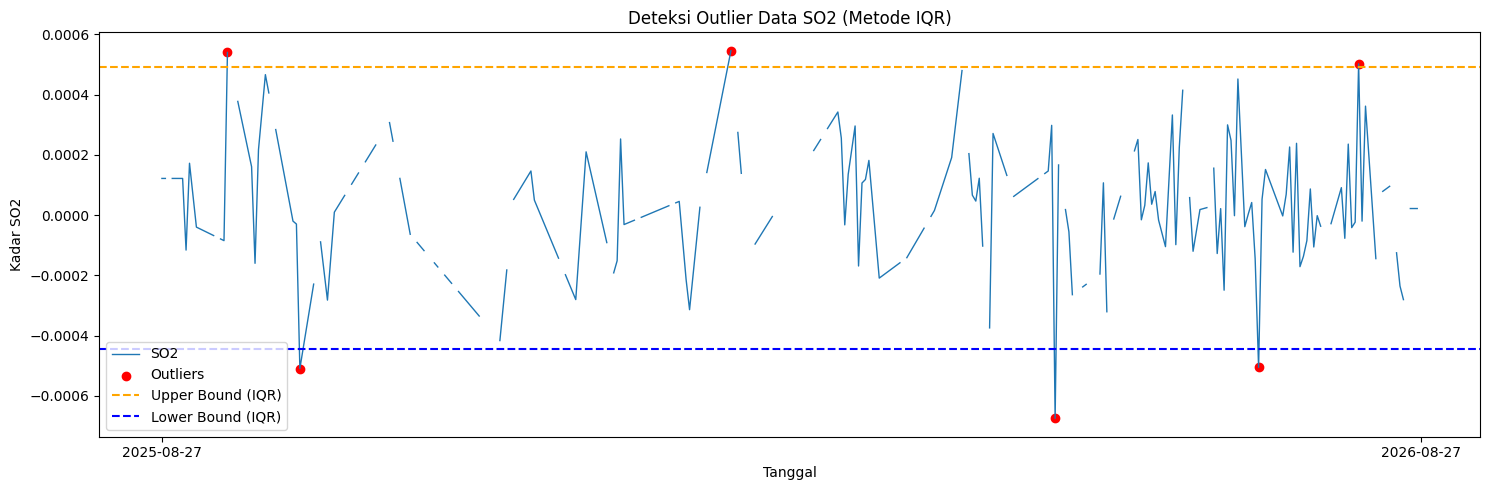

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Deteksi dan Visualisasi Outlier (Metode IQR) CO

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier (IQR):", len(outliers_iqr))
print(outliers_iqr[['date', 'CO']].head())

Jumlah Outlier (IQR): 5
          date        CO
43  2025-10-09  0.040473
320 2026-07-13  0.040105
347 2026-08-09  0.039287
348 2026-08-10  0.038860
357 2026-08-19  0.038800


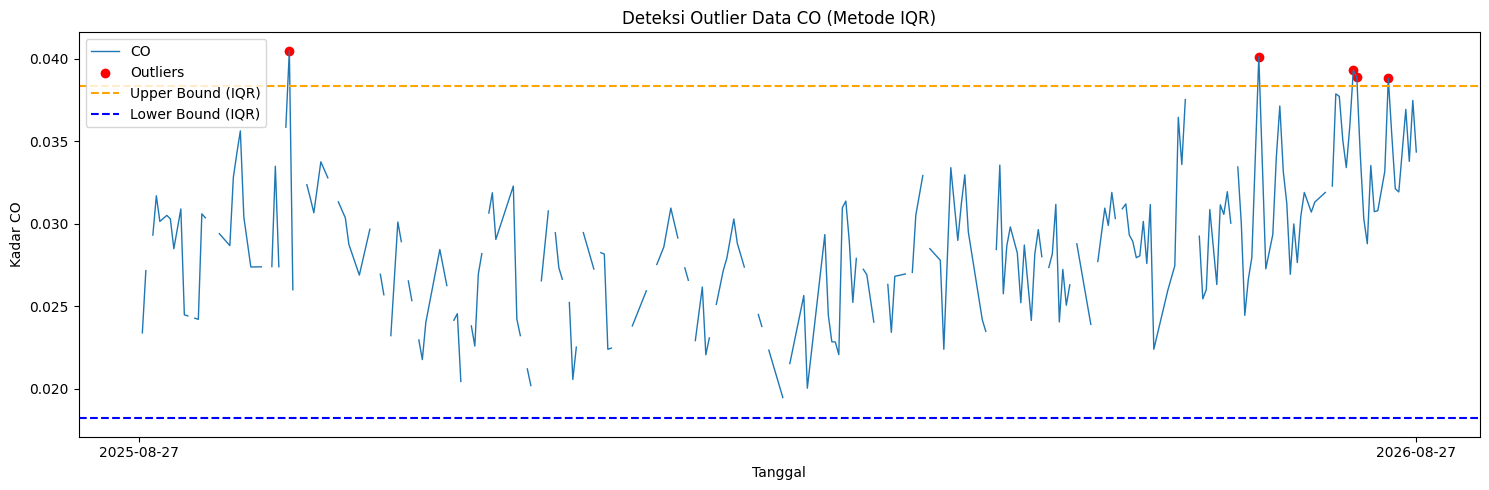

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan Outlier dan Interpolasi Data NO2

In [ ]:
import pandas as pd
import numpy as np

# 1. Ambil data asli
df = pd.read_csv("NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR awal
Q1_init = df['NO2'].quantile(0.25)
Q3_init = df['NO2'].quantile(0.75)
IQR_init = Q3_init - Q1_init
lower_init = Q1_init - 1.5 * IQR_init
upper_init = Q3_init + 1.5 * IQR_init

# 3. Ubah outlier awal menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_init) | (df['NO2'] > upper_init))

# 4. Interpolasi linear
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear')
df['NO2_filled'] = df['NO2_filled'].bfill().ffill()

# 5. Algoritma Iteratif untuk Menghilangkan Outlier Baru dengan Pengaman Presisi Desimal
data_final = df['NO2_filled'].copy()
while True:
    Q1_curr = data_final.quantile(0.25)
    Q3_curr = data_final.quantile(0.75)
    IQR_curr = Q3_curr - Q1_curr
    lower_curr = Q1_curr - 1.5 * IQR_curr
    upper_curr = Q3_curr + 1.5 * IQR_curr

    # Deteksi outlier
    outliers = data_final[(data_final < lower_curr) | (data_final > upper_curr)]
    if len(outliers) == 0:
        break # Selesai jika outlier sudah mutlak 0

    # Pangkas dengan margin pengaman kecil (1e-12) agar tidak terbentur masalah limit presisi desimal
    safe_lower = lower_curr + 1e-12
    safe_upper = upper_curr - 1e-12
    data_final = data_final.clip(lower=safe_lower, upper=safe_upper)

# 6. Simpan dataset final yang dijamin bebas outlier secara statistik
df_no2_warudoyong = pd.DataFrame({
    "date": df['date'],
    "NO2": data_final
})
df_no2_warudoyong.to_csv("NO2_Warudoyong_filled.csv", index=False)
print("Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.")

Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load data yang sudah diproses secara iteratif
df = pd.read_csv("NO2_Warudoyong_filled.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR akhir
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Cari outlier akhir
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier (IQR) Akhir setelah Capping Iteratif:", len(outliers_iqr))
print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

Jumlah Outlier (IQR) Akhir setelah Capping Iteratif: 0
Batas bawah: 2.6228252636428772e-06
Batas atas: 6.936550308485798e-05


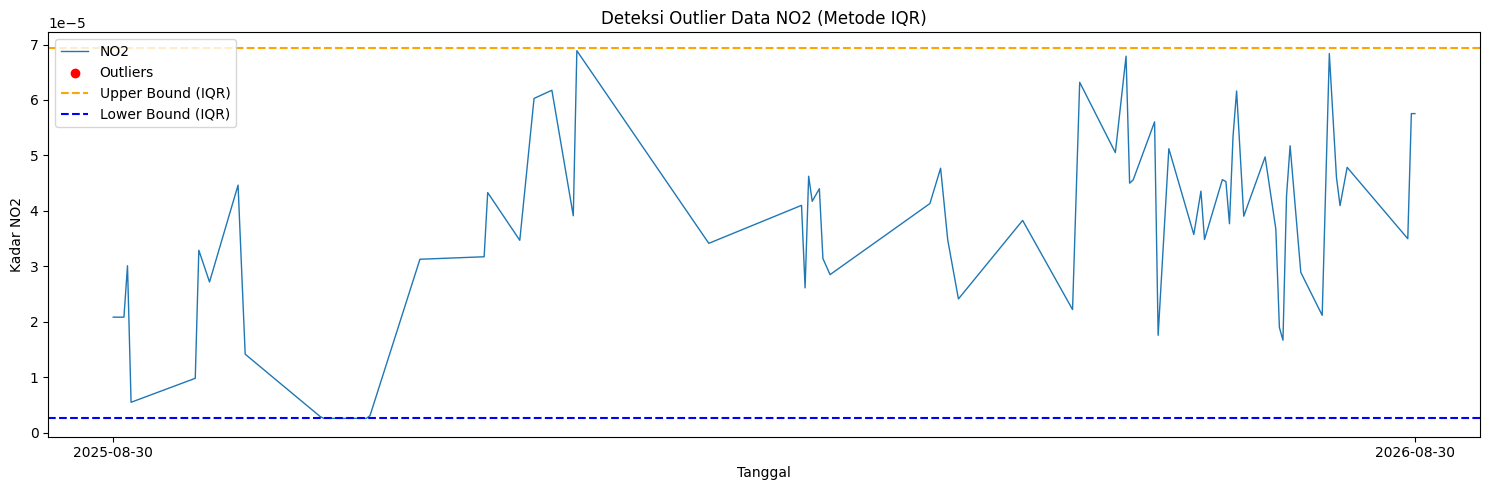

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan Outlier dan Interpolasi Data SO2

In [ ]:
import pandas as pd
import numpy as np

# 1. Ambil data asli
df = pd.read_csv("SO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR awal
Q1_init = df['SO2'].quantile(0.25)
Q3_init = df['SO2'].quantile(0.75)
IQR_init = Q3_init - Q1_init
lower_init = Q1_init - 1.5 * IQR_init
upper_init = Q3_init + 1.5 * IQR_init

# 3. Ubah outlier awal menjadi NaN
df['SO2_cleaned'] = df['SO2'].mask((df['SO2'] < lower_init) | (df['SO2'] > upper_init))

# 4. Interpolasi linear
df['SO2_filled'] = df['SO2_cleaned'].interpolate(method='linear')
df['SO2_filled'] = df['SO2_filled'].bfill().ffill()

# 5. Algoritma Iteratif untuk Menghilangkan Outlier Baru dengan Pengaman Presisi Desimal
data_final = df['SO2_filled'].copy()
while True:
    Q1_curr = data_final.quantile(0.25)
    Q3_curr = data_final.quantile(0.75)
    IQR_curr = Q3_curr - Q1_curr
    lower_curr = Q1_curr - 1.5 * IQR_curr
    upper_curr = Q3_curr + 1.5 * IQR_curr

    # Deteksi outlier
    outliers = data_final[(data_final < lower_curr) | (data_final > upper_curr)]
    if len(outliers) == 0:
        break # Selesai jika outlier sudah mutlak 0

    # Pangkas dengan margin pengaman kecil (1e-12) agar tidak terbentur masalah limit presisi desimal
    safe_lower = lower_curr + 1e-12
    safe_upper = upper_curr - 1e-12
    data_final = data_final.clip(lower=safe_lower, upper=safe_upper)

# 6. Simpan dataset final yang dijamin bebas outlier secara statistik
df_SO2_warudoyong = pd.DataFrame({
    "date": df['date'],
    "SO2": data_final
})
df_SO2_warudoyong.to_csv("SO2_Warudoyong_filled.csv", index=False)
print("Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.")

Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load data yang sudah diproses secara iteratif
df = pd.read_csv("SO2_Warudoyong_filled.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR akhir
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Cari outlier akhir
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier (IQR) Akhir setelah Capping Iteratif:", len(outliers_iqr))
print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

Jumlah Outlier (IQR) Akhir setelah Capping Iteratif: 0
Batas bawah: -0.00046624713750967496
Batas atas: 0.0005028181208357249


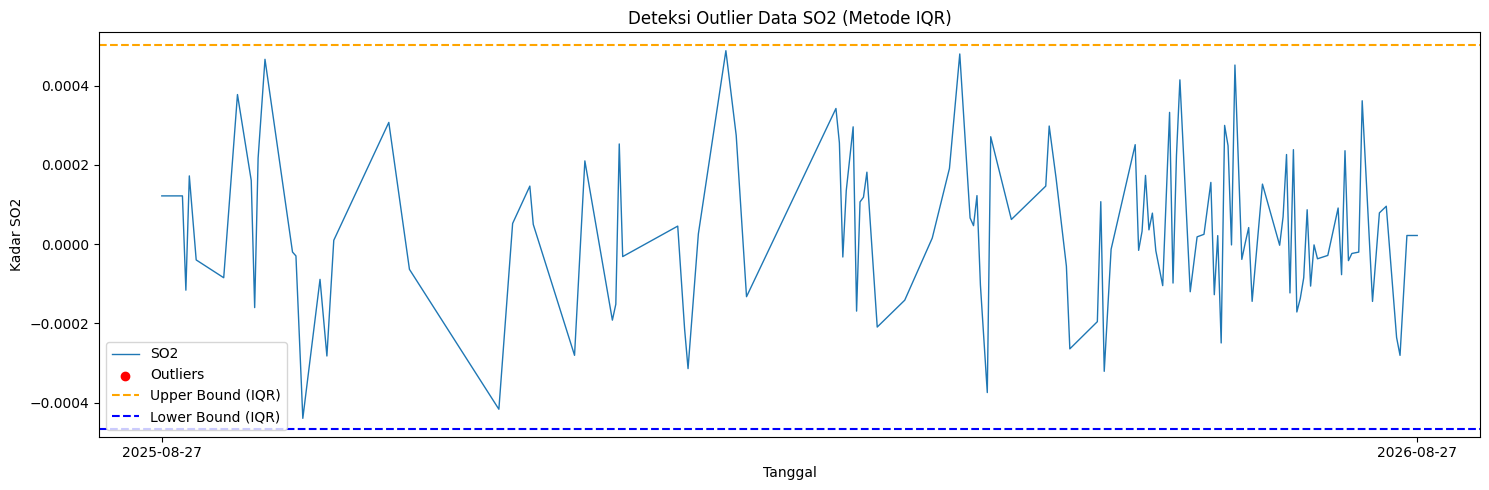

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan Outlier dan Interpolasi Data CO

In [ ]:
import pandas as pd
import numpy as np

# 1. Ambil data asli
df = pd.read_csv("CO_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR awal
Q1_init = df['CO'].quantile(0.25)
Q3_init = df['CO'].quantile(0.75)
IQR_init = Q3_init - Q1_init
lower_init = Q1_init - 1.5 * IQR_init
upper_init = Q3_init + 1.5 * IQR_init

# 3. Ubah outlier awal menjadi NaN
df['CO_cleaned'] = df['CO'].mask((df['CO'] < lower_init) | (df['CO'] > upper_init))

# 4. Interpolasi linear
df['CO_filled'] = df['CO_cleaned'].interpolate(method='linear')
df['CO_filled'] = df['CO_filled'].bfill().ffill()

# 5. Algoritma Iteratif untuk Menghilangkan Outlier Baru dengan Pengaman Presisi Desimal
data_final = df['CO_filled'].copy()
while True:
    Q1_curr = data_final.quantile(0.25)
    Q3_curr = data_final.quantile(0.75)
    IQR_curr = Q3_curr - Q1_curr
    lower_curr = Q1_curr - 1.5 * IQR_curr
    upper_curr = Q3_curr + 1.5 * IQR_curr

    # Deteksi outlier
    outliers = data_final[(data_final < lower_curr) | (data_final > upper_curr)]
    if len(outliers) == 0:
        break # Selesai jika outlier sudah mutlak 0

    # Pangkas dengan margin pengaman kecil (1e-12) agar tidak terbentur masalah limit presisi desimal
    safe_lower = lower_curr + 1e-12
    safe_upper = upper_curr - 1e-12
    data_final = data_final.clip(lower=safe_lower, upper=safe_upper)

# 6. Simpan dataset final yang dijamin bebas outlier secara statistik
df_CO_warudoyong = pd.DataFrame({
    "date": df['date'],
    "CO": data_final
})
df_CO_warudoyong.to_csv("CO_Warudoyong_filled.csv", index=False)
print("Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.")

Pemrosesan selesai! Silakan jalankan ulang sel ini sekarang, lalu jalankan sel pengecekan di bawahnya.


In [ ]:
import pandas as pd
import numpy as np

# 1. Load data yang sudah diproses secara iteratif
df = pd.read_csv("CO_Warudoyong_filled.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# 2. Hitung IQR akhir
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Cari outlier akhir
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier (IQR) Akhir setelah Capping Iteratif:", len(outliers_iqr))
print("Batas bawah:", lower_bound)
print("Batas atas:", upper_bound)

Jumlah Outlier (IQR) Akhir setelah Capping Iteratif: 0
Batas bawah: 0.017624364107508457
Batas atas: 0.038392963522875766


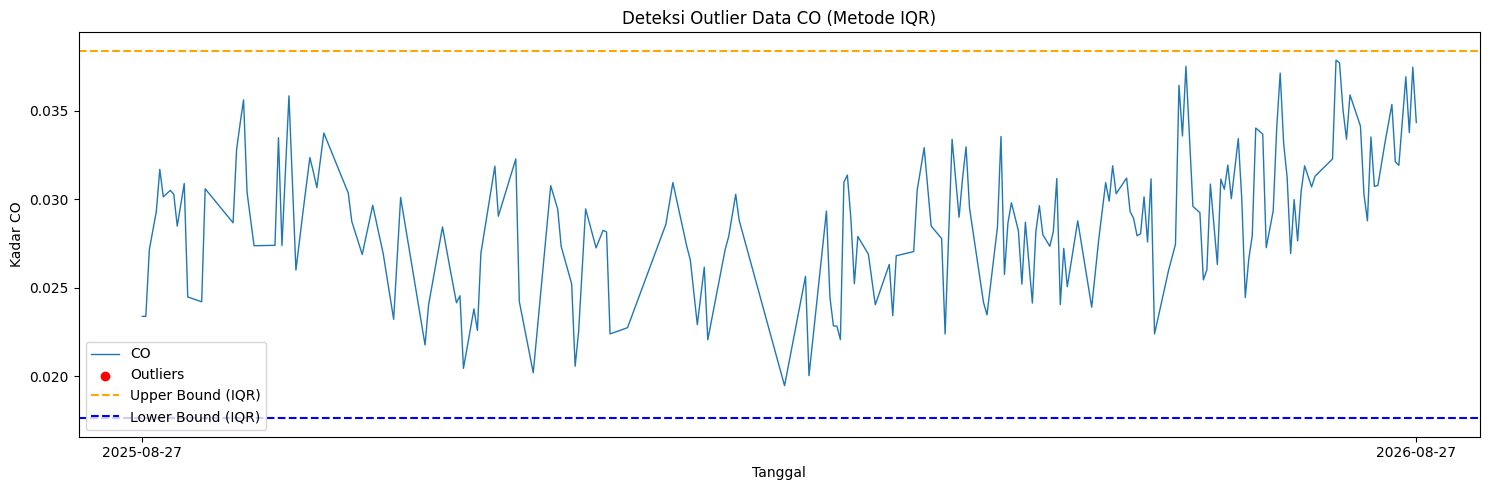

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

# Visualisasi Gabungan Setelah Preprocessing

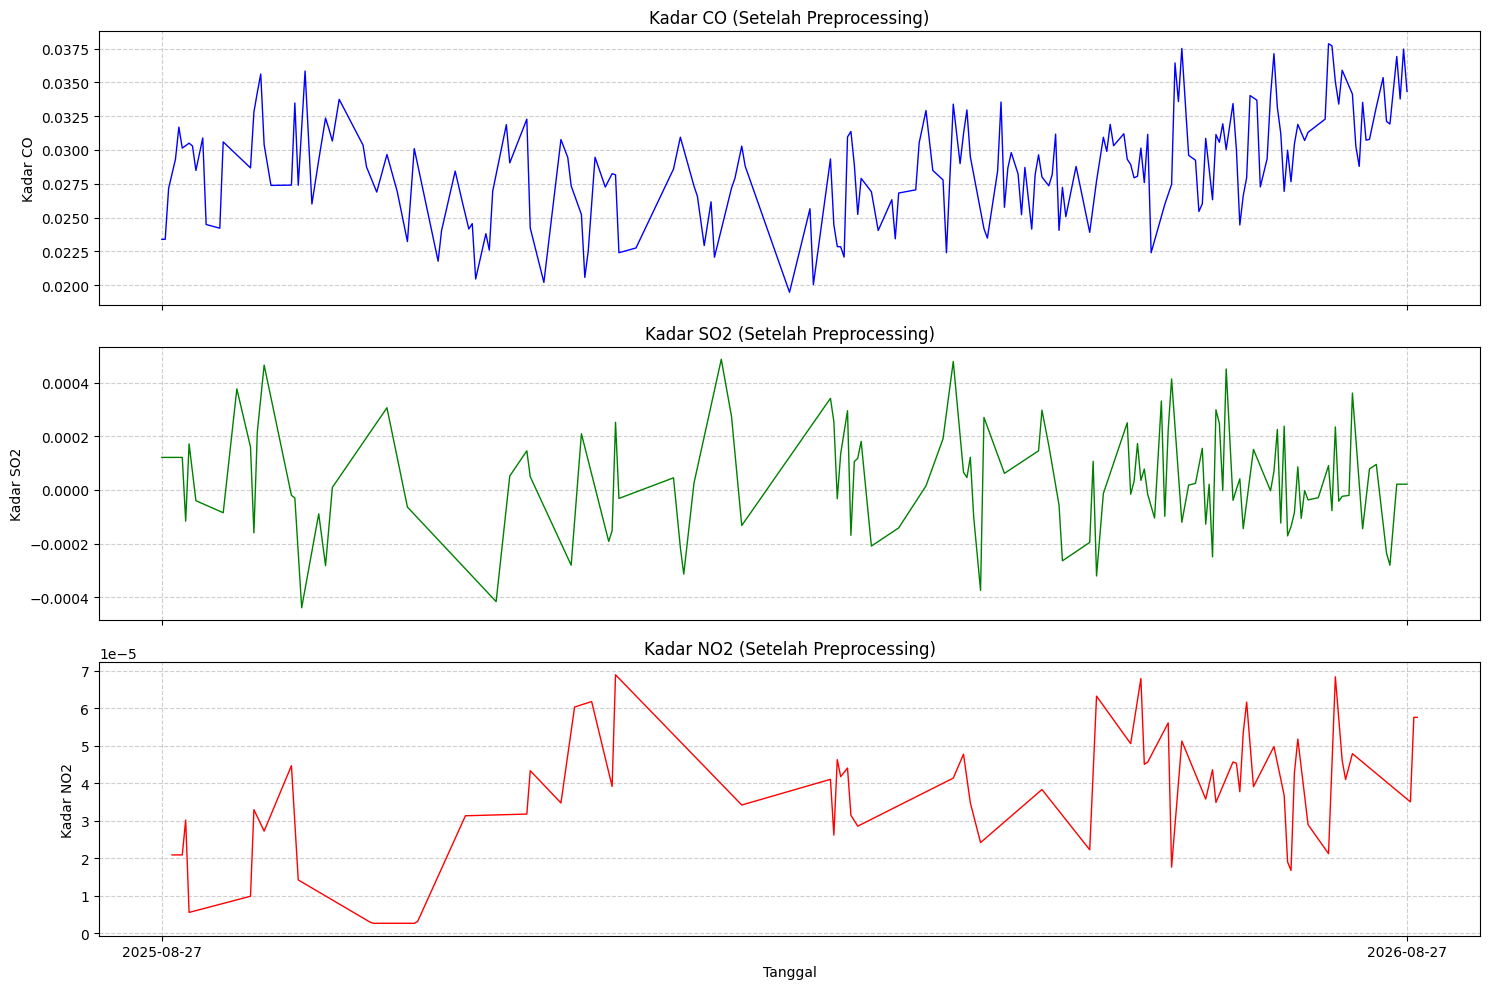

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Memuat data yang telah diproses
df_co = pd.read_csv("CO_Warudoyong_filled.csv")
df_so2 = pd.read_csv("SO2_Warudoyong_filled.csv")
df_no2 = pd.read_csv("NO2_Warudoyong_filled.csv")

df_co['date'] = pd.to_datetime(df_co['date'])
df_so2['date'] = pd.to_datetime(df_so2['date'])
df_no2['date'] = pd.to_datetime(df_no2['date'])

# Membuat subplot untuk ketiga polutan
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Plot CO
axes[0].plot(df_co['date'], df_co['CO'], color='blue', linewidth=1)
axes[0].set_title('Kadar CO (Setelah Preprocessing)')
axes[0].set_ylabel('Kadar CO')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot SO2
axes[1].plot(df_so2['date'], df_so2['SO2'], color='green', linewidth=1)
axes[1].set_title('Kadar SO2 (Setelah Preprocessing)')
axes[1].set_ylabel('Kadar SO2')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot NO2
axes[2].plot(df_no2['date'], df_no2['NO2'], color='red', linewidth=1)
axes[2].set_title('Kadar NO2 (Setelah Preprocessing)')
axes[2].set_xlabel('Tanggal')
axes[2].set_ylabel('Kadar NO2')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Menyesuaikan tampilan sumbu X
plt.xticks(
    ticks=[df_co['date'].iloc[0], df_co['date'].iloc[-1]],
    labels=[df_co['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.tight_layout()
plt.show()

#Penggabungan Data Polutan

In [ ]:
import pandas as pd

# Memuat data yang telah diproses
df_co = pd.read_csv("CO_Warudoyong_filled.csv")
df_so2 = pd.read_csv("SO2_Warudoyong_filled.csv")
df_no2 = pd.read_csv("NO2_Warudoyong_filled.csv")

dataframe_merged = pd.DataFrame({
    "date": df_no2['date'],
    "CO": df_co['CO'],
    "NO2": df_no2['NO2'],
    "SO2": df_so2['SO2']
})

dataframe_merged.to_csv("Polutan_Warudoyong_linier.csv", index=False)
print("Data polutan berhasil digabungkan dan disimpan")

EKSTRAKSI FITUR

In [ ]:
!pip install tsfel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 94.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat 1 file CSV utama yang berisi semua polutan ----------
df = pd.read_csv('Polutan_Warudoyong_linier.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = 1

# ---------- 2. Daftar 68 Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Dictionary untuk menampung seluruh hasil ekstraksi
combined_row = {}

# ---------- 4. Looping untuk membersihkan dan mengekstraksi tiap polutan ----------
for pollutant in pollutants:
    print(f"\n--- Memproses polutan: {pollutant} ---")

    df_poly = df[['date', pollutant]].copy()
    df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors='coerce')

    # Handling outlier dengan IQR (sebagai safeguard tambahan)
    Q1 = df_poly[pollutant].quantile(0.25)
    Q3 = df_poly[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[(df_poly[pollutant] < lower_bound) | (df_poly[pollutant] > upper_bound), pollutant] = np.nan

    # Interpolasi waktu dan cleaning
    df_clean = df_poly.set_index('date').interpolate(method='time').ffill().bfill()
    signal_1d = df_clean[pollutant].astype(float).values

    # Ekstraksi fitur dan beri prefix nama polutan (misal: NO2_abs_energy)
    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row[feature_key] = extract_one(fn_name, signal_1d, fs)

# ---------- 5. Simpan ke DataFrame final ----------
extracted_features_final = pd.DataFrame([combined_row])
print(f"\nBerhasil! Total kolom akhir yang dihasilkan: {extracted_features_final.shape[1]}")

output_filename = 'Warudoyong_linier.csv'
extracted_features_final.to_csv(output_filename, index=False)
print(f"File berhasil disimpan sebagai: {output_filename}")

Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

--- Memproses polutan: NO2 ---


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)



--- Memproses polutan: SO2 ---


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)



--- Memproses polutan: CO ---

Berhasil! Total kolom akhir yang dihasilkan: 204
File berhasil disimpan sebagai: Warudoyong_linier.csv


In [ ]:
df_feat = pd.read_csv("Warudoyong_linier.csv")
df_feat.head()

,NO2_abs_energy,NO2_auc,NO2_autocorr,NO2_average_power,NO2_calc_centroid,NO2_calc_max,NO2_calc_mean,NO2_calc_median,NO2_calc_min,NO2_calc_std,NO2_calc_var,NO2_dfa,NO2_distance,NO2_ecdf,NO2_ecdf_percentile,NO2_ecdf_percentile_count,NO2_ecdf_slope,NO2_entropy,NO2_fundamental_frequency,NO2_higuchi_fractal_dimension,NO2_hist_mode,NO2_human_range_energy,NO2_hurst_exponent,NO2_interq_range,NO2_kurtosis,NO2_lempel_ziv,NO2_lpcc,NO2_max_frequency,NO2_max_power_spectrum,NO2_maximum_fractal_length,NO2_mean_abs_deviation,NO2_mean_abs_diff,NO2_mean_diff,NO2_median_abs_deviation,NO2_median_abs_diff,NO2_median_diff,NO2_median_frequency,NO2_mfcc,NO2_mse,NO2_negative_turning,NO2_neighbourhood_peaks,NO2_petrosian_fractal_dimension,NO2_pk_pk_distance,NO2_positive_turning,NO2_power_bandwidth,NO2_rms,NO2_skewness,NO2_slope,NO2_spectral_centroid,NO2_spectral_decrease,NO2_spectral_distance,NO2_spectral_entropy,NO2_spectral_kurtosis,NO2_spectral_positive_turning,NO2_spectral_roll_off,NO2_spectral_roll_on,NO2_spectral_skewness,NO2_spectral_slope,NO2_spectral_spread,NO2_spectral_variation,NO2_spectrogram_mean_coeff,NO2_sum_abs_diff,NO2_wavelet_abs_mean,NO2_wavelet_energy,NO2_wavelet_entropy,NO2_wavelet_std,NO2_wavelet_var,NO2_zero_cross,SO2_abs_energy,SO2_auc,SO2_autocorr,SO2_average_power,SO2_calc_centroid,SO2_calc_max,SO2_calc_mean,SO2_calc_median,SO2_calc_min,SO2_calc_std,SO2_calc_var,SO2_dfa,SO2_distance,SO2_ecdf,SO2_ecdf_percentile,SO2_ecdf_percentile_count,SO2_ecdf_slope,SO2_entropy,SO2_fundamental_frequency,SO2_higuchi_fractal_dimension,SO2_hist_mode,SO2_human_range_energy,SO2_hurst_exponent,SO2_interq_range,SO2_kurtosis,SO2_lempel_ziv,SO2_lpcc,SO2_max_frequency,SO2_max_power_spectrum,SO2_maximum_fractal_length,SO2_mean_abs_deviation,SO2_mean_abs_diff,SO2_mean_diff,SO2_median_abs_deviation,SO2_median_abs_diff,SO2_median_diff,SO2_median_frequency,SO2_mfcc,SO2_mse,SO2_negative_turning,SO2_neighbourhood_peaks,SO2_petrosian_fractal_dimension,SO2_pk_pk_distance,SO2_positive_turning,SO2_power_bandwidth,SO2_rms,SO2_skewness,SO2_slope,SO2_spectral_centroid,SO2_spectral_decrease,SO2_spectral_distance,SO2_spectral_entropy,SO2_spectral_kurtosis,SO2_spectral_positive_turning,SO2_spectral_roll_off,SO2_spectral_roll_on,SO2_spectral_skewness,SO2_spectral_slope,SO2_spectral_spread,SO2_spectral_variation,SO2_spectrogram_mean_coeff,SO2_sum_abs_diff,SO2_wavelet_abs_mean,SO2_wavelet_energy,SO2_wavelet_entropy,SO2_wavelet_std,SO2_wavelet_var,SO2_zero_cross,CO_abs_energy,CO_auc,CO_autocorr,CO_average_power,CO_calc_centroid,CO_calc_max,CO_calc_mean,CO_calc_median,CO_calc_min,CO_calc_std,CO_calc_var,CO_dfa,CO_distance,CO_ecdf,CO_ecdf_percentile,CO_ecdf_percentile_count,CO_ecdf_slope,CO_entropy,CO_fundamental_frequency,CO_higuchi_fractal_dimension,CO_hist_mode,CO_human_range_energy,CO_hurst_exponent,CO_interq_range,CO_kurtosis,CO_lempel_ziv,CO_lpcc,CO_max_frequency,CO_max_power_spectrum,CO_maximum_fractal_length,CO_mean_abs_deviation,CO_mean_abs_diff,CO_mean_diff,CO_median_abs_deviation,CO_median_abs_diff,CO_median_diff,CO_median_frequency,CO_mfcc,CO_mse,CO_negative_turning,CO_neighbourhood_peaks,CO_petrosian_fractal_dimension,CO_pk_pk_distance,CO_positive_turning,CO_power_bandwidth,CO_rms,CO_skewness,CO_slope,CO_spectral_centroid,CO_spectral_decrease,CO_spectral_distance,CO_spectral_entropy,CO_spectral_kurtosis,CO_spectral_positive_turning,CO_spectral_roll_off,CO_spectral_roll_on,CO_spectral_skewness,CO_spectral_slope,CO_spectral_spread,CO_spectral_variation,CO_spectrogram_mean_coeff,CO_sum_abs_diff,CO_wavelet_abs_mean,CO_wavelet_energy,CO_wavelet_entropy,CO_wavelet_std,CO_wavelet_var,CO_zero_cross
0,5.329787e-07,0.012644,29.0,1.460216e-09,213.869221,0.000069,0.000035,0.000037,0.000003,0.000016,2.552693e-10,1.256499,365.0,0.015027,0.000034,182.5,32739.118615,0.981357,0.005464,1.559069,0.000039,0.0,0.972563,0.000017,-0.357879,0.128415,0.791776,0.374317,61.505252,-2.906207,0.000012,0.000003,1.005209e-07,0.000008,9.382257e-07,2.499756e-08,0.019126,9.198422,0.815558,21.0,1

interpolasi polinomial

CO

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("CO_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier CO (IQR):", len(outliers_iqr))

Jumlah Outlier CO (IQR): 5


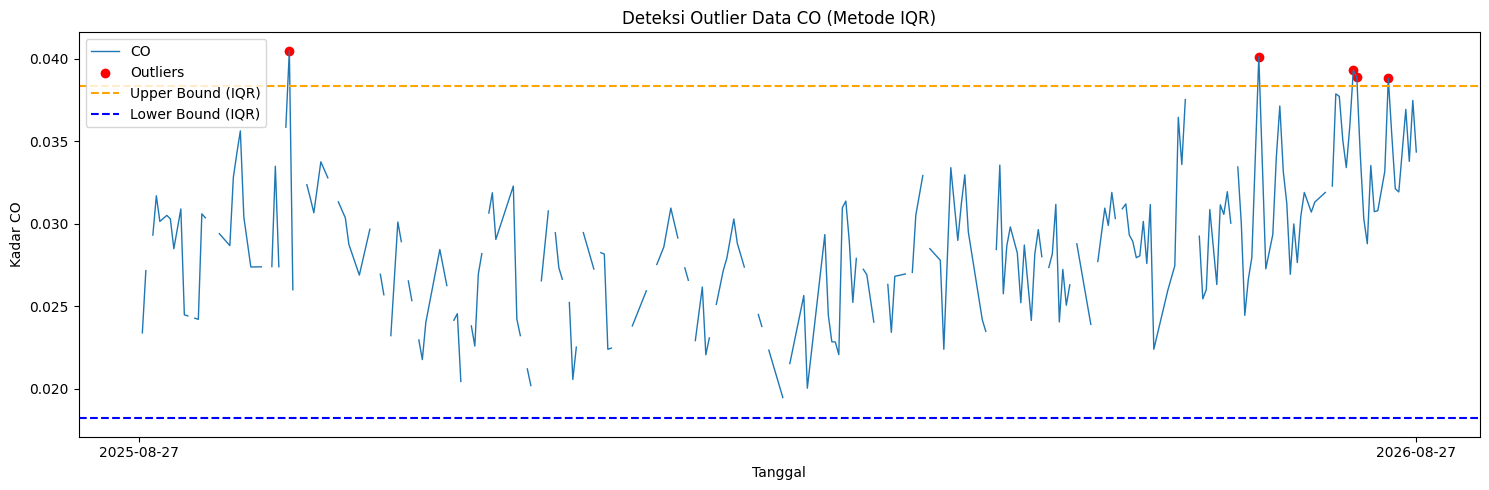

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan outlier dan pengisian nilai yang hilang untuk CO:

In [ ]:
df['CO_filled'] = df['CO'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['CO_filled'].quantile(0.25)
    Q3 = df['CO_filled'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 2. Deteksi lokasi outlier
    outliers = (df['CO_filled'] < lower_bound) | (df['CO_filled'] > upper_bound)

    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break

    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan interpolasi polinomial + bfill + ffill
    df['CO_filled'] = df['CO_filled'].mask(outliers)
    df['CO_filled'] = df['CO_filled'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_co = pd.DataFrame({"date": df['date'], "CO": df['CO_filled']})
df_co.to_csv("CO_filed_polynomial.csv", index=False)
print("Data CO berhasil diproses dan disimpan ke CO_filed_polynomial.csv")

Data CO berhasil diproses dan disimpan ke CO_filed_polynomial.csv


Visualisasi data CO setelah proses interpolasi (memastikan sudah tidak ada outlier):

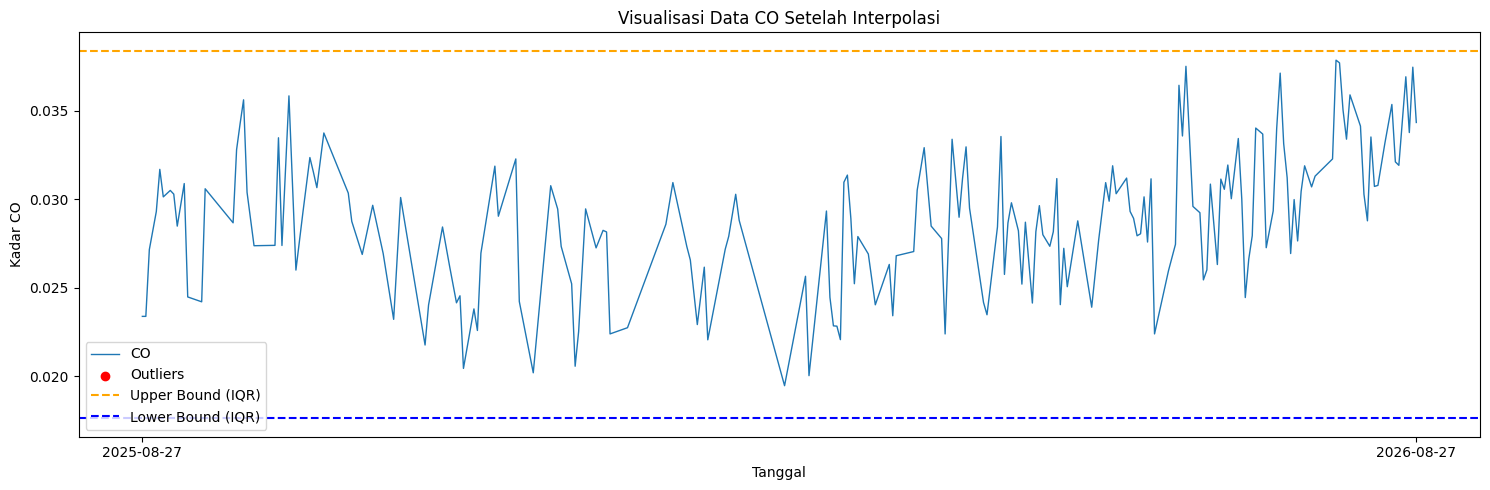

In [ ]:
df_co_final = pd.read_csv("CO_filed_polynomial.csv")
df_co_final['date'] = pd.to_datetime(df_co_final['date'])

Q1 = df_co_final['CO'].quantile(0.25)
Q3 = df_co_final['CO'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_co_final[(df_co_final['CO'] < lower_bound) | (df_co_final['CO'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df_co_final['date'], df_co_final['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Visualisasi Data CO Setelah Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_co_final['date'].iloc[0], df_co_final['date'].iloc[-1]],
    labels=[df_co_final['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co_final['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

SO2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("SO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier SO2 (IQR):", len(outliers_iqr))

Jumlah Outlier SO2 (IQR): 6


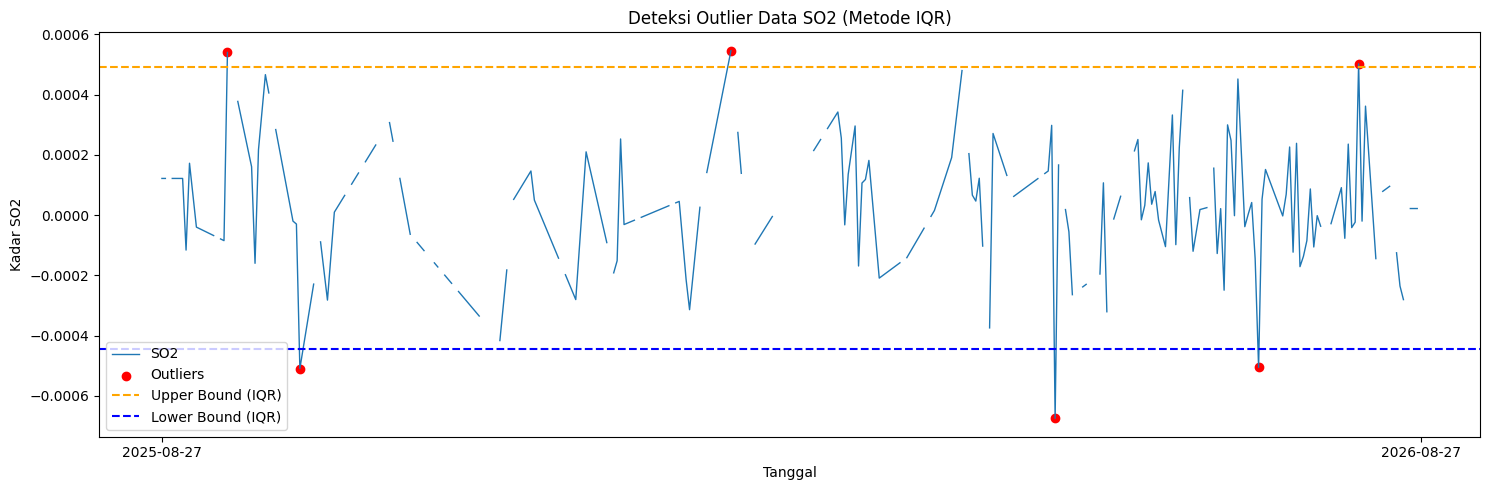

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan outlier dan pengisian nilai yang hilang untuk SO2:

In [ ]:
df['SO2_filled'] = df['SO2'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['SO2_filled'].quantile(0.25)
    Q3 = df['SO2_filled'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 2. Deteksi lokasi outlier
    outliers = (df['SO2_filled'] < lower_bound) | (df['SO2_filled'] > upper_bound)

    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break

    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan interpolasi polinomial + bfill + ffill
    df['SO2_filled'] = df['SO2_filled'].mask(outliers)
    df['SO2_filled'] = df['SO2_filled'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_so2 = pd.DataFrame({"date": df['date'], "SO2": df['SO2_filled']})
df_so2.to_csv("SO2_filed_polynomial.csv", index=False)
print("Data SO2 berhasil diproses dan disimpan ke SO2_filed_polynomial.csv")

Data SO2 berhasil diproses dan disimpan ke SO2_filed_polynomial.csv


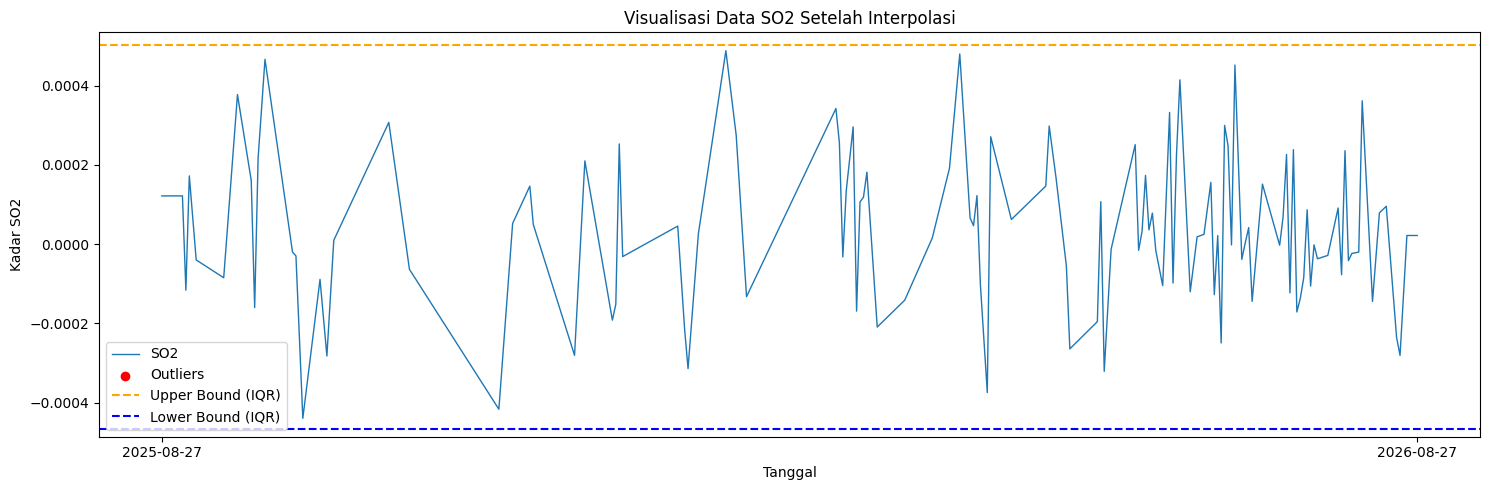

In [ ]:
df_so2_final = pd.read_csv("SO2_filed_polynomial.csv")
df_so2_final['date'] = pd.to_datetime(df_so2_final['date'])

Q1 = df_so2_final['SO2'].quantile(0.25)
Q3 = df_so2_final['SO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_so2_final[(df_so2_final['SO2'] < lower_bound) | (df_so2_final['SO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df_so2_final['date'], df_so2_final['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Visualisasi Data SO2 Setelah Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_so2_final['date'].iloc[0], df_so2_final['date'].iloc[-1]],
    labels=[df_so2_final['date'].iloc[0].strftime('%Y-%m-%d'),
            df_so2_final['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

NO2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("NO2_Timeseries.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['NO2'] = pd.to_numeric(df['NO2'], errors='coerce')

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier NO2 (IQR):", len(outliers_iqr))

Jumlah Outlier NO2 (IQR): 7


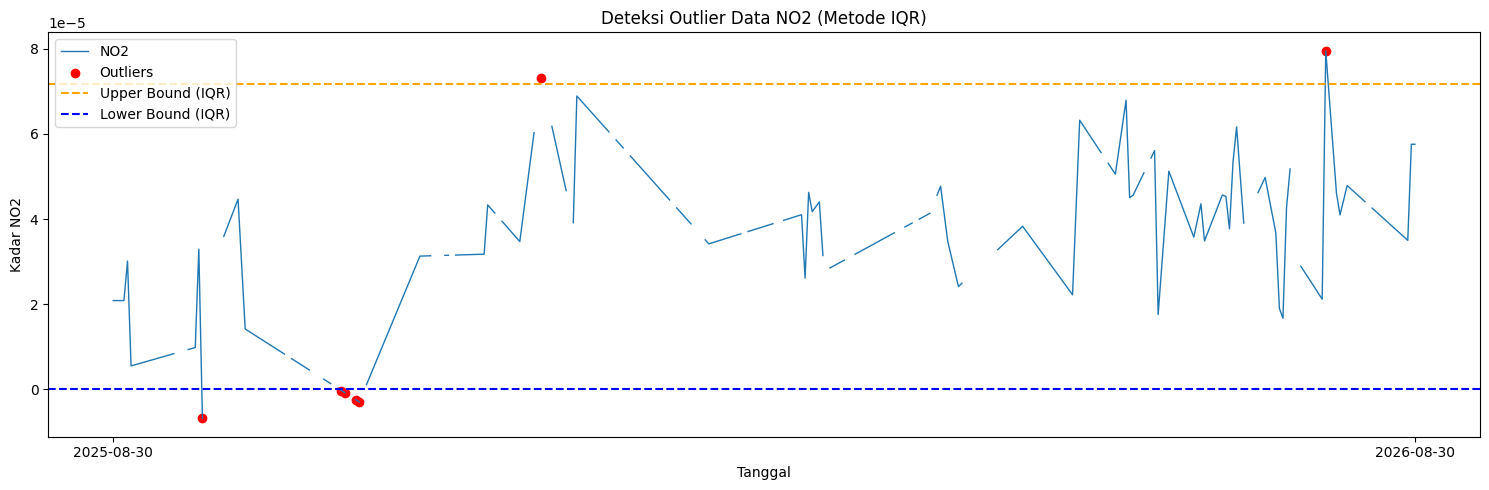

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan outlier dan pengisian nilai yang hilang untuk NO2:

In [ ]:
df['NO2_filled'] = df['NO2'].copy()

# Looping iteratif untuk membersihkan outlier sampai benar-benar habis
while True:
    # 1. Hitung ulang kuartil dan batas IQR berdasarkan data saat ini
    Q1 = df['NO2_filled'].quantile(0.25)
    Q3 = df['NO2_filled'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 2. Deteksi lokasi outlier
    outliers = (df['NO2_filled'] < lower_bound) | (df['NO2_filled'] > upper_bound)

    # Jika sudah tidak ada outlier yang terdeteksi, hentikan perulangan
    if not outliers.any():
        break

    # 3. Mask nilai outlier menjadi NaN, lalu isi dengan interpolasi polinomial + bfill + ffill
    df['NO2_filled'] = df['NO2_filled'].mask(outliers)
    df['NO2_filled'] = df['NO2_filled'].interpolate(method='polynomial', order=1).bfill().ffill()

# 4. Simpan hasil akhir ke DataFrame baru dan ekspor ke CSV
df_no2 = pd.DataFrame({"date": df['date'], "NO2": df['NO2_filled']})
df_no2.to_csv("NO2_filed_polynomial.csv", index=False)
print("Data NO2 berhasil diproses dan disimpan ke NO2_filed_polynomial.csv")

Data NO2 berhasil diproses dan disimpan ke NO2_filed_polynomial.csv


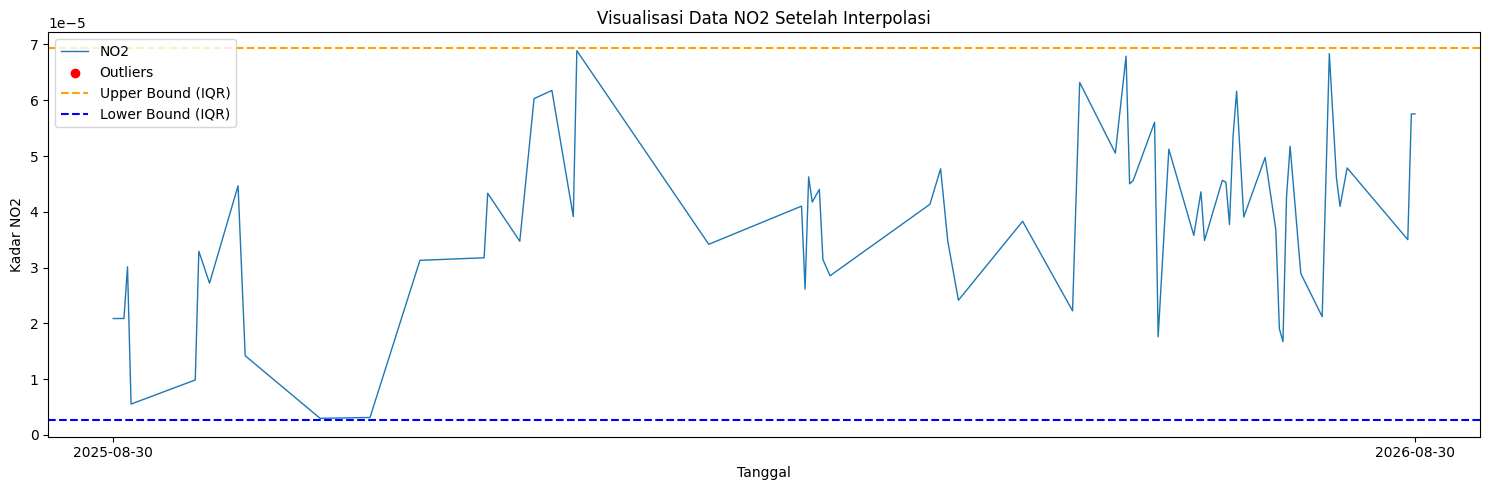

In [ ]:
df_no2_final = pd.read_csv("NO2_filed_polynomial.csv")
df_no2_final['date'] = pd.to_datetime(df_no2_final['date'])

Q1 = df_no2_final['NO2'].quantile(0.25)
Q3 = df_no2_final['NO2'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_no2_final[(df_no2_final['NO2'] < lower_bound) | (df_no2_final['NO2'] > upper_bound)]

plt.figure(figsize=(15,5))
plt.plot(df_no2_final['date'], df_no2_final['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Visualisasi Data NO2 Setelah Interpolasi")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df_no2_final['date'].iloc[0], df_no2_final['date'].iloc[-1]],
    labels=[df_no2_final['date'].iloc[0].strftime('%Y-%m-%d'),
            df_no2_final['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Visualisasi Gabungan Setelah Preprocessing

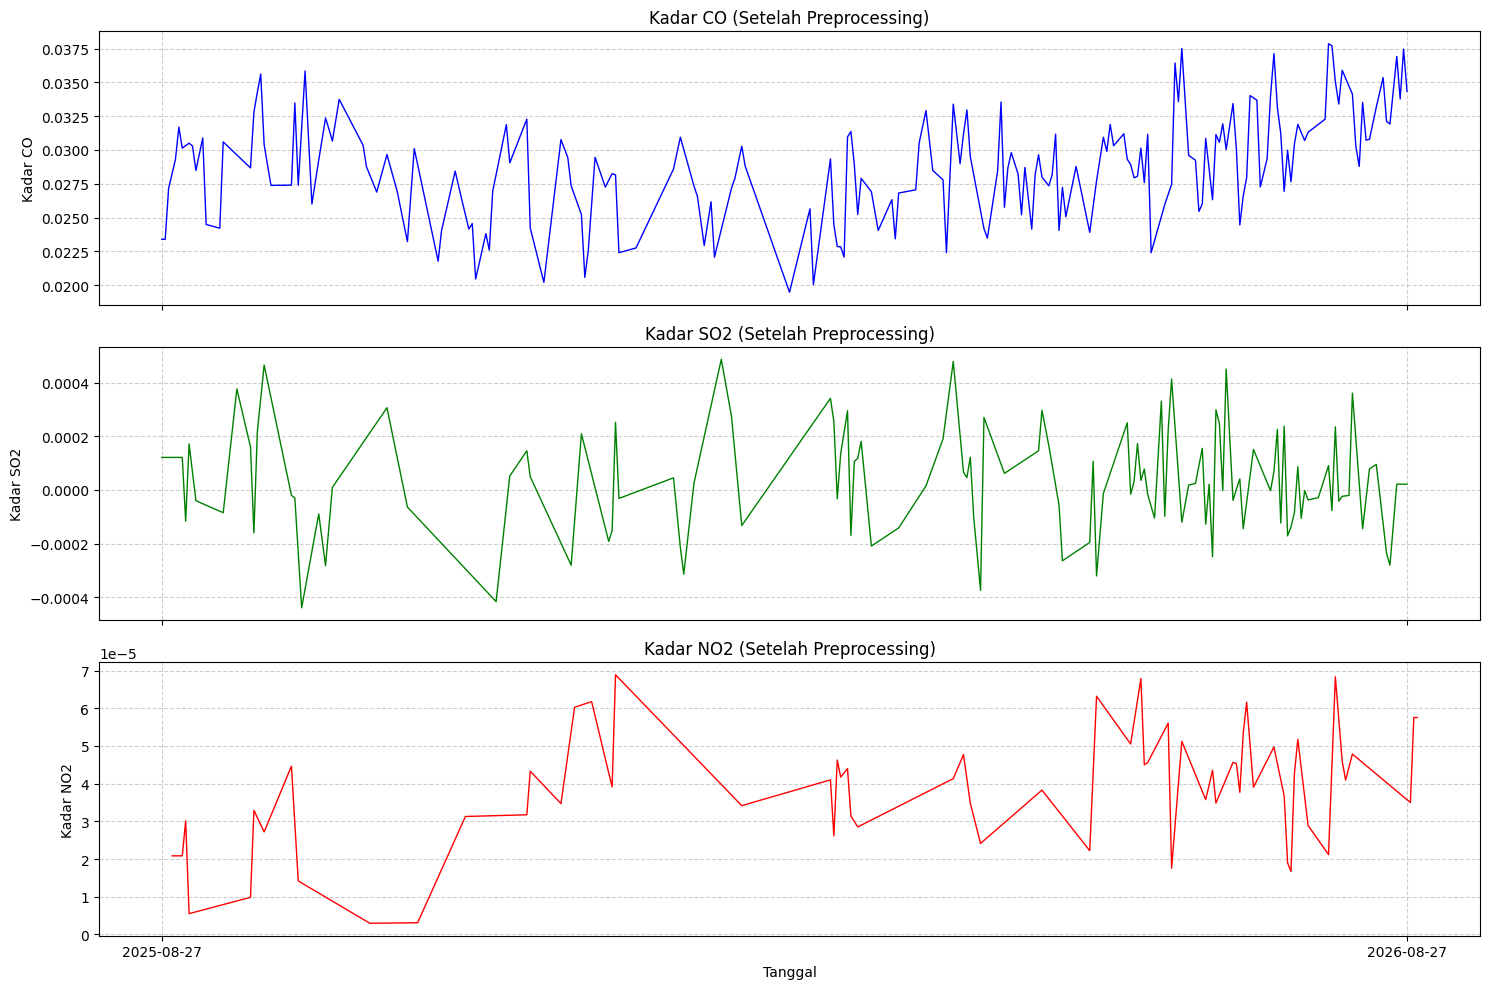

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Memuat data yang telah diproses
df_co = pd.read_csv("CO_filed_polynomial.csv")
df_so2 = pd.read_csv("SO2_filed_polynomial.csv")
df_no2 = pd.read_csv("NO2_filed_polynomial.csv")

df_co['date'] = pd.to_datetime(df_co['date'])
df_so2['date'] = pd.to_datetime(df_so2['date'])
df_no2['date'] = pd.to_datetime(df_no2['date'])

# Membuat subplot untuk ketiga polutan
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Plot CO
axes[0].plot(df_co['date'], df_co['CO'], color='blue', linewidth=1)
axes[0].set_title('Kadar CO (Setelah Preprocessing)')
axes[0].set_ylabel('Kadar CO')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot SO2
axes[1].plot(df_so2['date'], df_so2['SO2'], color='green', linewidth=1)
axes[1].set_title('Kadar SO2 (Setelah Preprocessing)')
axes[1].set_ylabel('Kadar SO2')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot NO2
axes[2].plot(df_no2['date'], df_no2['NO2'], color='red', linewidth=1)
axes[2].set_title('Kadar NO2 (Setelah Preprocessing)')
axes[2].set_xlabel('Tanggal')
axes[2].set_ylabel('Kadar NO2')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Menyesuaikan tampilan sumbu X
plt.xticks(
    ticks=[df_co['date'].iloc[0], df_co['date'].iloc[-1]],
    labels=[df_co['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.tight_layout()
plt.show()

Selain divisualisasikan dalam subplot terpisah, kita juga dapat menumpuk (overlay) ketiga polutan dalam satu grafik untuk membandingkan fluktuasinya secara langsung. Karena skala kadar polutan mungkin berbeda, perbandingan ini difokuskan pada pengamatan pola tren perubahannya.

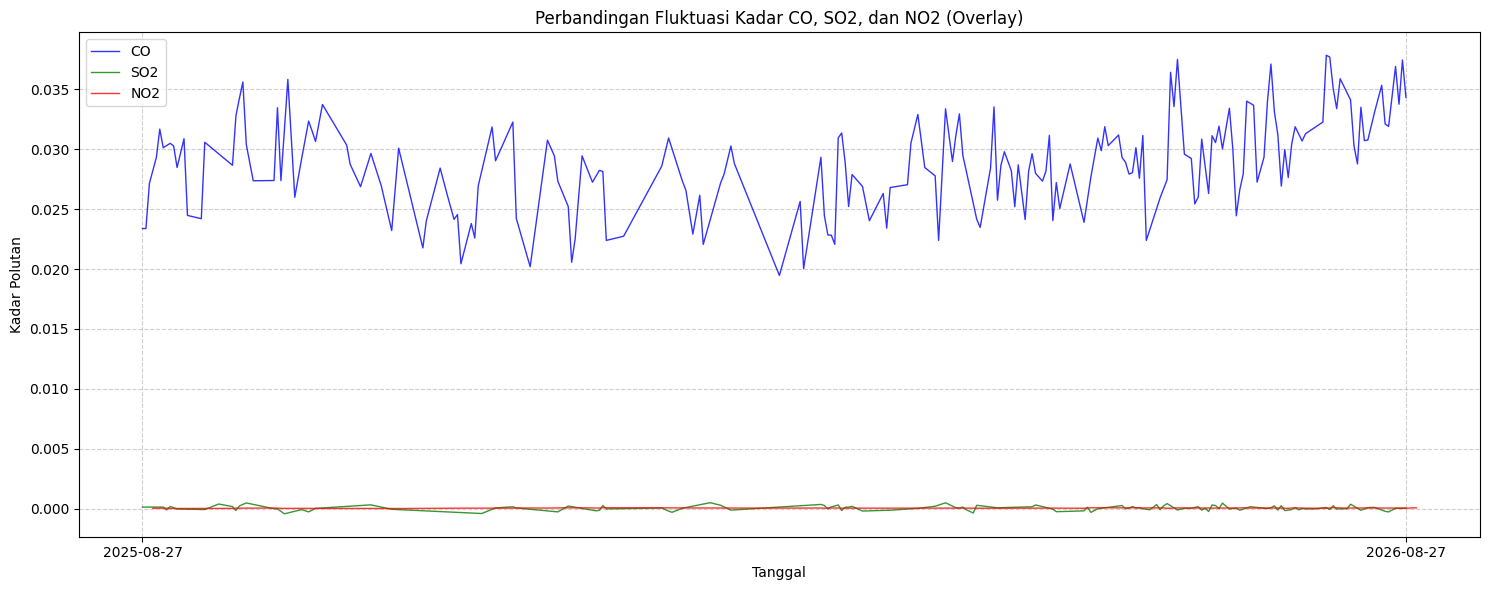

In [ ]:
plt.figure(figsize=(15, 6))

# Plot ketiga polutan dalam satu axis
plt.plot(df_co['date'], df_co['CO'], color='blue', label='CO', linewidth=1, alpha=0.8)
plt.plot(df_so2['date'], df_so2['SO2'], color='green', label='SO2', linewidth=1, alpha=0.8)
plt.plot(df_no2['date'], df_no2['NO2'], color='red', label='NO2', linewidth=1, alpha=0.8)

plt.title('Perbandingan Fluktuasi Kadar CO, SO2, dan NO2 (Overlay)')
plt.xlabel('Tanggal')
plt.ylabel('Kadar Polutan')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Menyesuaikan tampilan sumbu X
plt.xticks(
    ticks=[df_co['date'].iloc[0], df_co['date'].iloc[-1]],
    labels=[df_co['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.tight_layout()
plt.show()

Penggabungan Data Polutan

In [ ]:
import pandas as pd

# Memuat data yang telah diproses
df_co = pd.read_csv("CO_filed_polynomial.csv")
df_no2 = pd.read_csv("NO2_filed_polynomial.csv")
df_so2 = pd.read_csv("SO2_filed_polynomial.csv")

dataframe_merged = pd.DataFrame({
    "date": df_no2['date'],
    "CO": df_co['CO'],
    "NO2": df_no2['NO2'],
    "SO2": df_so2['SO2']
})

dataframe_merged.to_csv("Polutan_Warudoyong_polynomial.csv", index=False)
print("Data polutan berhasil digabungkan dan disimpan ke Polutan_Baron_polynomial.csv")

Data polutan berhasil digabungkan dan disimpan ke Polutan_Baron_polynomial.csv


Ekstraksi Fitur Deret Waktu

In [ ]:
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat 1 file CSV utama yang berisi semua polutan ----------
df = pd.read_csv('Polutan_Warudoyong_polynomial.csv')

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

pollutants = ['NO2', 'SO2', 'CO']
fs = 1

# ---------- 2. Daftar 68 Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

print(f"Jumlah fitur per polutan: {len(FEATURE_LIST)}")
print(f"Total target fitur keseluruhan: {len(FEATURE_LIST) * len(pollutants)}")

# ---------- 3. Fungsi ekstraksi dan penyeragaman output  ----------
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)

def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Dictionary untuk menampung seluruh hasil ekstraksi
combined_row = {}

# ---------- 4. Looping untuk membersihkan dan mengekstraksi tiap polutan ----------
for pollutant in pollutants:
    print(f"\n--- Memproses polutan: {pollutant} ---")

    df_poly = df[['date', pollutant]].copy()
    df_poly[pollutant] = pd.to_numeric(df_poly[pollutant], errors='coerce')

    # Handling outlier dengan IQR (sebagai safeguard tambahan)
    Q1 = df_poly[pollutant].quantile(0.25)
    Q3 = df_poly[pollutant].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_poly.loc[(df_poly[pollutant] < lower_bound) | (df_poly[pollutant] > upper_bound), pollutant] = np.nan

    # Interpolasi waktu dan cleaning
    df_clean = df_poly.set_index('date').interpolate(method='time').ffill().bfill()
    signal_1d = df_clean[pollutant].astype(float).values

    # Ekstraksi fitur dan beri prefix nama polutan (misal: NO2_abs_energy)
    for fn_name in FEATURE_LIST:
        feature_key = f"{pollutant}_{fn_name}"
        combined_row[feature_key] = extract_one(fn_name, signal_1d, fs)

# ---------- 5. Simpan ke DataFrame final ----------
extracted_features_final = pd.DataFrame([combined_row])
print(f"\nBerhasil! Total kolom akhir yang dihasilkan: {extracted_features_final.shape[1]}")

output_filename = 'Warudoyong_Polynomial.csv'
extracted_features_final.to_csv(output_filename, index=False)
print(f"File berhasil disimpan sebagai: {output_filename}")

Jumlah fitur per polutan: 68
Total target fitur keseluruhan: 204

--- Memproses polutan: NO2 ---


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)



--- Memproses polutan: SO2 ---


/usr/local/lib/python3.13/dist-packages/tsfel/feature_extraction/features_utils.py:534: RuntimeWarning: invalid value encountered in divide
  rs = np.divide(r, s)



--- Memproses polutan: CO ---

Berhasil! Total kolom akhir yang dihasilkan: 204
File berhasil disimpan sebagai: Warudoyong_Polynomial.csv


In [ ]:
df_feat = pd.read_csv("Warudoyong_Polynomial.csv")
df_feat.head()

,NO2_abs_energy,NO2_auc,NO2_autocorr,NO2_average_power,NO2_calc_centroid,NO2_calc_max,NO2_calc_mean,NO2_calc_median,NO2_calc_min,NO2_calc_std,NO2_calc_var,NO2_dfa,NO2_distance,NO2_ecdf,NO2_ecdf_percentile,NO2_ecdf_percentile_count,NO2_ecdf_slope,NO2_entropy,NO2_fundamental_frequency,NO2_higuchi_fractal_dimension,NO2_hist_mode,NO2_human_range_energy,NO2_hurst_exponent,NO2_interq_range,NO2_kurtosis,NO2_lempel_ziv,NO2_lpcc,NO2_max_frequency,NO2_max_power_spectrum,NO2_maximum_fractal_length,NO2_mean_abs_deviation,NO2_mean_abs_diff,NO2_mean_diff,NO2_median_abs_deviation,NO2_median_abs_diff,NO2_median_diff,NO2_median_frequency,NO2_mfcc,NO2_mse,NO2_negative_turning,NO2_neighbourhood_peaks,NO2_petrosian_fractal_dimension,NO2_pk_pk_distance,NO2_positive_turning,NO2_power_bandwidth,NO2_rms,NO2_skewness,NO2_slope,NO2_spectral_centroid,NO2_spectral_decrease,NO2_spectral_distance,NO2_spectral_entropy,NO2_spectral_kurtosis,NO2_spectral_positive_turning,NO2_spectral_roll_off,NO2_spectral_roll_on,NO2_spectral_skewness,NO2_spectral_slope,NO2_spectral_spread,NO2_spectral_variation,NO2_spectrogram_mean_coeff,NO2_sum_abs_diff,NO2_wavelet_abs_mean,NO2_wavelet_energy,NO2_wavelet_entropy,NO2_wavelet_std,NO2_wavelet_var,NO2_zero_cross,SO2_abs_energy,SO2_auc,SO2_autocorr,SO2_average_power,SO2_calc_centroid,SO2_calc_max,SO2_calc_mean,SO2_calc_median,SO2_calc_min,SO2_calc_std,SO2_calc_var,SO2_dfa,SO2_distance,SO2_ecdf,SO2_ecdf_percentile,SO2_ecdf_percentile_count,SO2_ecdf_slope,SO2_entropy,SO2_fundamental_frequency,SO2_higuchi_fractal_dimension,SO2_hist_mode,SO2_human_range_energy,SO2_hurst_exponent,SO2_interq_range,SO2_kurtosis,SO2_lempel_ziv,SO2_lpcc,SO2_max_frequency,SO2_max_power_spectrum,SO2_maximum_fractal_length,SO2_mean_abs_deviation,SO2_mean_abs_diff,SO2_mean_diff,SO2_median_abs_deviation,SO2_median_abs_diff,SO2_median_diff,SO2_median_frequency,SO2_mfcc,SO2_mse,SO2_negative_turning,SO2_neighbourhood_peaks,SO2_petrosian_fractal_dimension,SO2_pk_pk_distance,SO2_positive_turning,SO2_power_bandwidth,SO2_rms,SO2_skewness,SO2_slope,SO2_spectral_centroid,SO2_spectral_decrease,SO2_spectral_distance,SO2_spectral_entropy,SO2_spectral_kurtosis,SO2_spectral_positive_turning,SO2_spectral_roll_off,SO2_spectral_roll_on,SO2_spectral_skewness,SO2_spectral_slope,SO2_spectral_spread,SO2_spectral_variation,SO2_spectrogram_mean_coeff,SO2_sum_abs_diff,SO2_wavelet_abs_mean,SO2_wavelet_energy,SO2_wavelet_entropy,SO2_wavelet_std,SO2_wavelet_var,SO2_zero_cross,CO_abs_energy,CO_auc,CO_autocorr,CO_average_power,CO_calc_centroid,CO_calc_max,CO_calc_mean,CO_calc_median,CO_calc_min,CO_calc_std,CO_calc_var,CO_dfa,CO_distance,CO_ecdf,CO_ecdf_percentile,CO_ecdf_percentile_count,CO_ecdf_slope,CO_entropy,CO_fundamental_frequency,CO_higuchi_fractal_dimension,CO_hist_mode,CO_human_range_energy,CO_hurst_exponent,CO_interq_range,CO_kurtosis,CO_lempel_ziv,CO_lpcc,CO_max_frequency,CO_max_power_spectrum,CO_maximum_fractal_length,CO_mean_abs_deviation,CO_mean_abs_diff,CO_mean_diff,CO_median_abs_deviation,CO_median_abs_diff,CO_median_diff,CO_median_frequency,CO_mfcc,CO_mse,CO_negative_turning,CO_neighbourhood_peaks,CO_petrosian_fractal_dimension,CO_pk_pk_distance,CO_positive_turning,CO_power_bandwidth,CO_rms,CO_skewness,CO_slope,CO_spectral_centroid,CO_spectral_decrease,CO_spectral_distance,CO_spectral_entropy,CO_spectral_kurtosis,CO_spectral_positive_turning,CO_spectral_roll_off,CO_spectral_roll_on,CO_spectral_skewness,CO_spectral_slope,CO_spectral_spread,CO_spectral_variation,CO_spectrogram_mean_coeff,CO_sum_abs_diff,CO_wavelet_abs_mean,CO_wavelet_energy,CO_wavelet_entropy,CO_wavelet_std,CO_wavelet_var,CO_zero_cross
0,5.330091e-07,0.01265,29.0,1.460299e-09,213.860761,0.000069,0.000035,0.000037,0.000003,0.000016,2.543363e-10,1.255333,365.0,0.015027,0.000034,182.5,32739.118615,0.996792,0.005464,1.559565,0.000039,0.0,0.939937,0.000017,-0.366548,0.128415,0.792045,0.374317,61.58488,-2.906546,0.000012,0.000003,1.005209e-07,0.000008,9.382257e-07,2.499756e-08,0.019126,9.196055,0.816856,22.0,11.

#K-Means Clustering Polutan


##Implementasi K-Means dengan Python (Scikit-Learn)

Evaluasi Jumlah Cluster (Elbow Method)

NO2

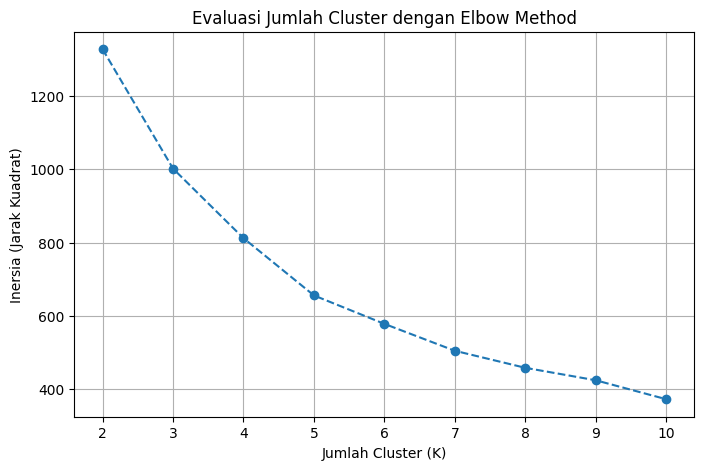

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_no2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

SO2

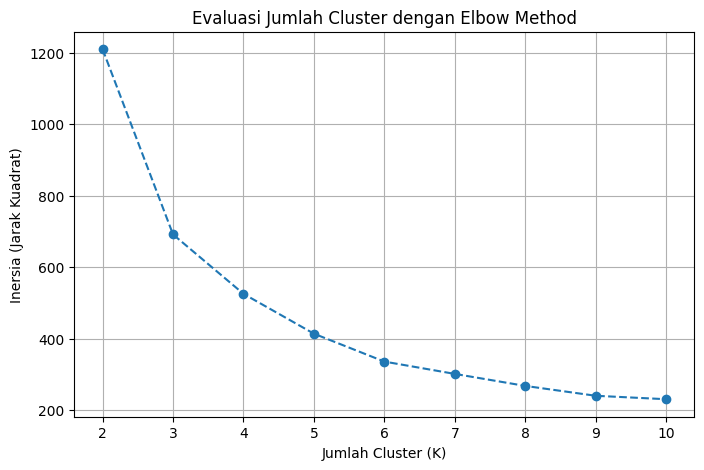

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_so2.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

CO

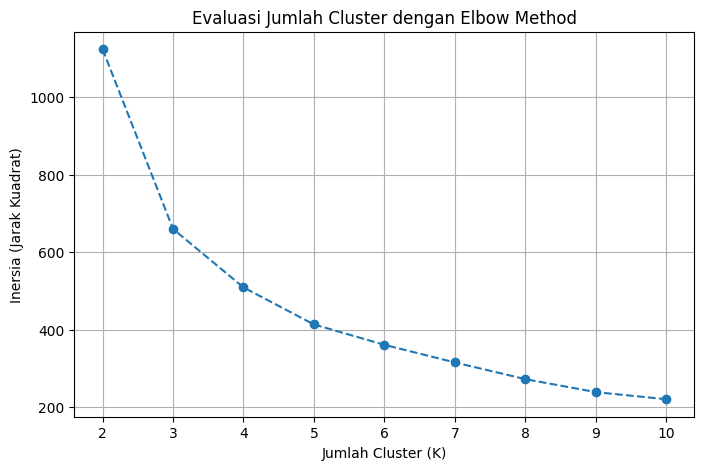

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df = pd.read_csv('ekstraksi_fitur_co.csv')
fitur = df.drop(['id', 'nama', 'daerah'], axis=1)

scaler = StandardScaler()
fitur_scaled = scaler.fit_transform(fitur)
fitur_pca = PCA(n_components=37).fit_transform(fitur_scaled)

inertia = []
K_range = range(2, 11)
for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(fitur_pca)
    inertia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--')
plt.title('Evaluasi Jumlah Cluster dengan Elbow Method')
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inersia (Jarak Kuadrat)')
plt.grid(True)
plt.show()

Visualisasi Scatter Plot PCA dan Profiling

NO2

PCA: 68 fitur -> 37 dimensi

Inertia: 655.7898

Jumlah data per cluster:
cluster_label
cluster_0     2
cluster_1    22
cluster_2     1
cluster_3     1
cluster_4    11
Name: count, dtype: int64


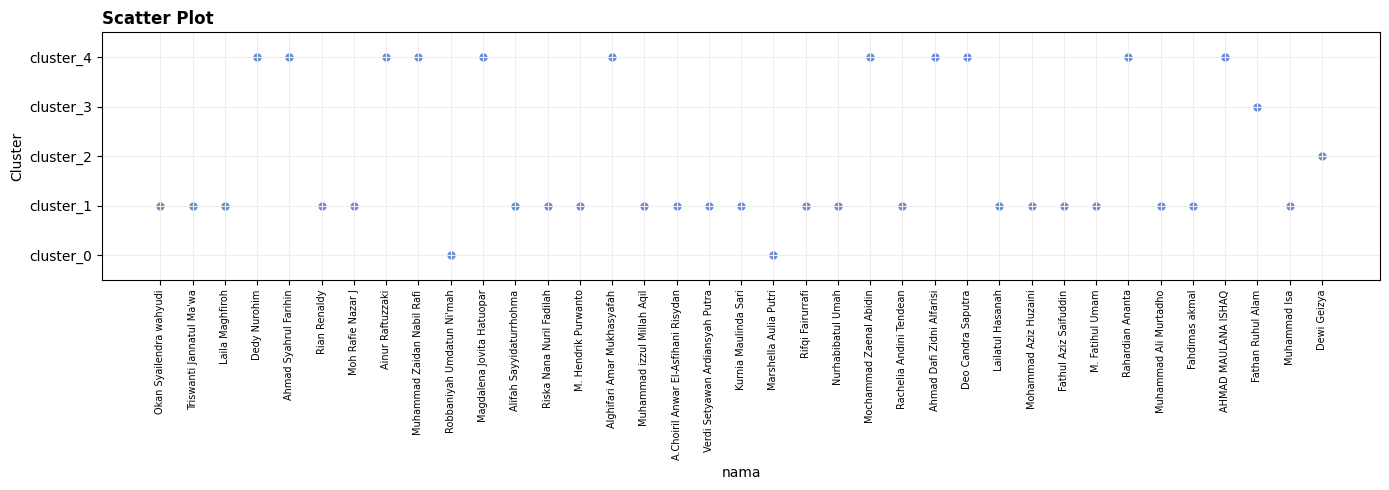

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CSV_PATH = "ekstraksi_fitur_no2.csv"
KOLOM_NAMA = "nama"
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()
K = 5
N_DIMENSI = 37
GUNAKAN_SCALING = True

if N_DIMENSI > len(KOLOM_FITUR):
    raise ValueError(
        f"N_DIMENSI ({N_DIMENSI}) tidak boleh lebih besar dari jumlah fitur ({len(KOLOM_FITUR)})."
    )

#  Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()


if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# PCA
pca = PCA(n_components=N_DIMENSI, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA: {len(KOLOM_FITUR)} fitur -> {N_DIMENSI} dimensi")

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# Hasil
print(f"\nInertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# Scatter plot
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()

SO2

PCA: 68 fitur -> 37 dimensi

Inertia: 413.6787

Jumlah data per cluster:
cluster_label
cluster_0     3
cluster_1    31
cluster_2     1
cluster_3     1
cluster_4     1
Name: count, dtype: int64


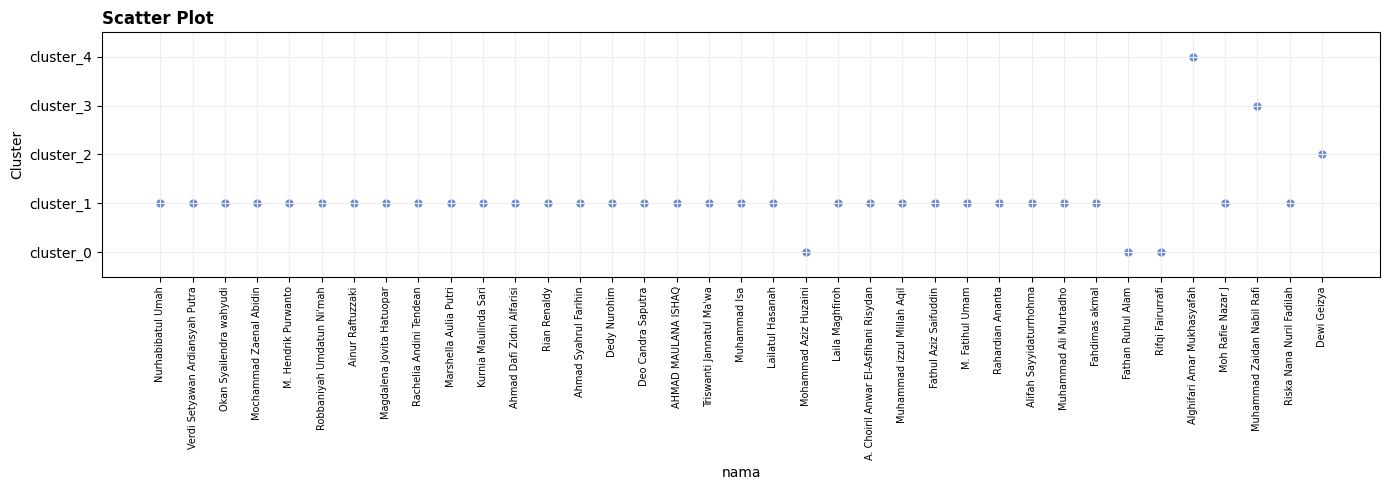

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CSV_PATH = "ekstraksi_fitur_so2.csv"
KOLOM_NAMA = "nama"
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()
K = 5
N_DIMENSI = 37
GUNAKAN_SCALING = True

if N_DIMENSI > len(KOLOM_FITUR):
    raise ValueError(
        f"N_DIMENSI ({N_DIMENSI}) tidak boleh lebih besar dari jumlah fitur ({len(KOLOM_FITUR)})."
    )

#  Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()


if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# PCA
pca = PCA(n_components=N_DIMENSI, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA: {len(KOLOM_FITUR)} fitur -> {N_DIMENSI} dimensi")

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# Hasil
print(f"\nInertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# Scatter plot
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()

CO

PCA: 68 fitur -> 37 dimensi

Inertia: 413.8895

Jumlah data per cluster:
cluster_label
cluster_0    12
cluster_1     1
cluster_2     2
cluster_3     1
cluster_4    21
Name: count, dtype: int64


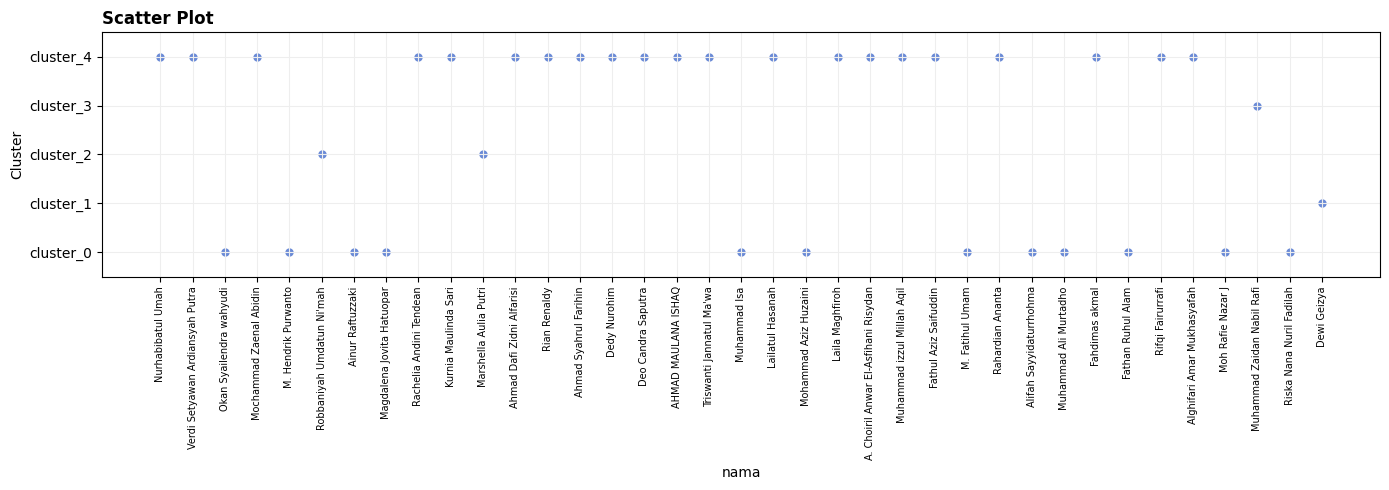

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

CSV_PATH = "ekstraksi_fitur_co.csv"
KOLOM_NAMA = "nama"
KOLOM_FITUR = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()
K = 5
N_DIMENSI = 37
GUNAKAN_SCALING = True

if N_DIMENSI > len(KOLOM_FITUR):
    raise ValueError(
        f"N_DIMENSI ({N_DIMENSI}) tidak boleh lebih besar dari jumlah fitur ({len(KOLOM_FITUR)})."
    )

#  Baca data
df = pd.read_csv(CSV_PATH)
data = df.dropna(subset=KOLOM_FITUR).copy()


if GUNAKAN_SCALING:
    X = StandardScaler().fit_transform(data[KOLOM_FITUR])
else:
    X = data[KOLOM_FITUR].values

# PCA
pca = PCA(n_components=N_DIMENSI, random_state=42)
X_pca = pca.fit_transform(X)

print(f"PCA: {len(KOLOM_FITUR)} fitur -> {N_DIMENSI} dimensi")

# K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
data["cluster"] = kmeans.fit_predict(X_pca)
data["cluster_label"] = "cluster_" + data["cluster"].astype(str)

# Hasil
print(f"\nInertia: {kmeans.inertia_:.4f}")
print("\nJumlah data per cluster:")
print(data["cluster_label"].value_counts().sort_index())

# Scatter plot
label_cluster = [f"cluster_{i}" for i in range(K)]
y = data["cluster"]
x = range(len(data))

plt.figure(figsize=(14, 5))
plt.scatter(x, y, s=25, color="#6b8bd6")
plt.xticks(x, data[KOLOM_NAMA], rotation=90, fontsize=7)
plt.yticks(range(K), label_cluster)
plt.ylim(-0.5, K - 0.5)
plt.title("Scatter Plot", loc="left", fontweight="bold")
plt.xlabel("nama")
plt.ylabel("Cluster")
plt.grid(True, color="#eeeeee")
plt.tight_layout()
plt.show()